# Spam-Erkennung in SMS: Baseline und TF-IDF mit logistischer Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/projektarbeit_beispiel.ipynb)

## 1 Fragestellung

Erkennt eine logistische Regression auf TF-IDF-Merkmalen Spam in englischen SMS besser als eine Baseline, die jede SMS als Nicht-Spam einstuft?

**Anwendungsfall.** Ein Mobilfunkanbieter prüft eingehende SMS, bevor sie das Telefon erreichen, und verschiebt Spam in einen eigenen Ordner.

**Metrik.** F1 der Klasse Spam auf den Testdaten. Die Accuracy belohnt die Baseline: Wer nie Spam meldet, liegt bei 87 % Nicht-Spam in 87 % der Fälle richtig.

In [1]:
import csv
import io
import re
import urllib.request
import zipfile
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

SEED = 42  # fester Seed: jeder Lauf erzeugt dieselbe Aufteilung und dieselben Zahlen
DATA_URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

## 2 Daten

**Quelle.** SMS Spam Collection v.1, Almeida und Gómez Hidalgo (2011), UCI Machine Learning Repository, [doi:10.24432/C5CC84](https://doi.org/10.24432/C5CC84). Begleitpublikation: Almeida, Gómez Hidalgo und Yamakami (2011), *Contributions to the Study of SMS Spam Filtering: New Collection and Results*, ACM DocEng.

**Lizenz.** CC BY 4.0.

**Sprache.** Englisch. Jede Zeile enthält ein Label (`ham` für Nicht-Spam, `spam`) und den Text der SMS.

**Herkunft.** Laut der mitgelieferten readme-Datei stammen 3'375 der 4'827 Nicht-Spam-SMS aus dem NUS SMS Corpus der National University of Singapore; laut readme stammen diese SMS grösstenteils von Personen aus Singapur, meist Studierenden der Universität. 425 der 747 Spam-SMS stammen aus dem britischen Forum Grumbletext, 322 aus dem SMS Spam Corpus v.0.1.

In [2]:
def load_sms(url=DATA_URL):
    """Lädt die SMS Spam Collection und gibt eine Tabelle mit den Spalten label und text zurück."""
    try:
        with urllib.request.urlopen(url, timeout=60) as response:
            archive = zipfile.ZipFile(io.BytesIO(response.read()))
    except OSError as error:
        raise SystemExit(f"Download fehlgeschlagen: {url}\n{error}")
    with archive.open("SMSSpamCollection") as f:
        return pd.read_csv(f, sep="\t", header=None, names=["label", "text"],
                           quoting=csv.QUOTE_NONE, encoding="utf-8")


sms = load_sms()
print(f"SMS: {len(sms):,}   Wörter: {sms.text.str.split().str.len().sum():,}")
print(sms.label.value_counts().to_string())
sms.sample(3, random_state=SEED)

SMS: 5,574   Wörter: 86,908
label
ham     4827
spam     747


,label,text
3690,ham,You still coming tonight?
3527,ham,"""HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE..."
724,ham,Ya even those cookies have jelly on them


### Bereinigung

Gleiche SMS-Texte kommen mehrfach vor. Eine SMS, die im Training und im Test steht, macht den Test leichter, als er im Einsatz ist. Doppelte Texte werden deshalb vor der Aufteilung entfernt. Dieser Schritt lernt nichts aus den Daten; alles, was lernt, das Vokabular von TF-IDF und die Gewichte der Regression, sieht nur die Trainingsdaten. Weitere Schritte übernimmt der TF-IDF-Vektorisierer: Kleinschreibung und Zerlegung in Wörter aus mindestens zwei Zeichen.

In [3]:
duplicates = sms.duplicated("text").sum()
sms = sms.drop_duplicates("text").reset_index(drop=True)
print(f"entfernte Duplikate: {duplicates}   verbleibende SMS: {len(sms):,}")
counts = sms.label.value_counts()
print(pd.DataFrame({"Anzahl": counts, "Anteil": (counts / len(sms)).round(3)}).to_string())

entfernte Duplikate: 403   verbleibende SMS: 5,171
       Anzahl  Anteil
label                
ham      4518   0.874
spam      653   0.126


## 3 Deskriptive Analyse

Drei Kennzahlen: die Länge der SMS, die häufigsten Wörter und die Grösse des Wortschatzes, jeweils getrennt nach Klasse.

label
ham      53.0
spam    148.0


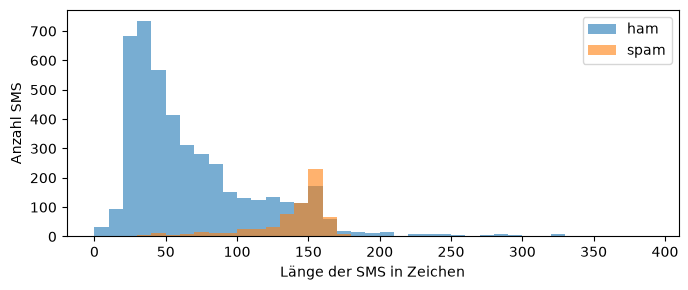

In [4]:
sms["chars"] = sms.text.str.len()
print(sms.groupby("label").chars.median().rename("Median Zeichen").to_string())

fig, ax = plt.subplots(figsize=(7, 3))
for label, color in [("ham", "tab:blue"), ("spam", "tab:orange")]:
    ax.hist(sms.chars[sms.label == label], bins=range(0, 400, 10), alpha=0.6, color=color, label=label)
ax.set_xlabel("Länge der SMS in Zeichen")
ax.set_ylabel("Anzahl SMS")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
def words(text):
    """Kleingeschriebene Wörter aus mindestens zwei Zeichen, wie sie der TF-IDF-Vektorisierer sieht."""
    return re.findall(r"\b\w\w+\b", text.lower())


for label in ["ham", "spam"]:
    counter = Counter(w for t in sms.text[sms.label == label] for w in words(t) if w not in ENGLISH_STOP_WORDS)
    print(label, [w for w, _ in counter.most_common(10)])

ham ['gt', 'lt', 'just', 'ok', 'll', 'got', 'know', 'like', 'good', 'come']
spam ['free', 'txt', 'ur', 'stop', 'mobile', 'text', 'claim', 'reply', 'www', 'prize']


In [6]:
vocabulary = {label: {w for t in sms.text[sms.label == label] for w in words(t)} for label in ["ham", "spam"]}
print(f"Wortschatz gesamt: {len(vocabulary['ham'] | vocabulary['spam']):,}")
print(f"nur in ham: {len(vocabulary['ham'] - vocabulary['spam']):,}   nur in spam: {len(vocabulary['spam'] - vocabulary['ham']):,}")

Wortschatz gesamt: 8,713
nur in ham: 5,851   nur in spam: 1,809


Spam-SMS sind fast dreimal so lang wie Nicht-Spam-SMS (Median 148 gegen 53 Zeichen). Unter ihren häufigsten Wörtern stehen *free*, *txt*, *claim*, *reply* und *prize*, also Aufforderungen und Angebote. Die Nicht-Spam-SMS enthalten Alltagswörter wie *ok*, *got* und *come* und die Zeichenfolgen *gt* und *lt*.

## 4 Trainings- und Testdaten

80 % der SMS dienen dem Training, 20 % dem Test. Die Aufteilung ist stratifiziert, sodass beide Teile denselben Spam-Anteil haben. Die Testdaten bleiben bis zur Evaluation unberührt.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    sms.text, sms.label, test_size=0.2, stratify=sms.label, random_state=SEED)
print(f"Training: {len(X_train):,} SMS   Test: {len(X_test):,} SMS, davon Spam: {(y_test == 'spam').sum()}")

Training: 4,136 SMS   Test: 1,035 SMS, davon Spam: 131


## 5 Methoden

**Baseline.** Die häufigste Klasse: Jede SMS gilt als Nicht-Spam.

**Methode aus dem Kurs.** TF-IDF-Merkmale (Kapitel 4, Word Representations) und eine logistische Regression, die Textklassifikation der Modulbeschreibung. Begründung der Wahl: 4'136 kurze Trainingstexte genügen für ein lineares Modell, das Training läuft ohne GPU, und jedes Wort erhält ein Gewicht, das sich lesen lässt.

In [8]:
models = {
    "Baseline (häufigste Klasse)": DummyClassifier(strategy="most_frequent"),
    "TF-IDF + logistische Regression": make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000)),
}
for model in models.values():
    model.fit(X_train, y_train)

## 6 Evaluation

In [9]:
def evaluate(model):
    """Accuracy sowie Precision, Recall und F1 der Klasse Spam auf den Testdaten."""
    predicted = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, predicted),
        "Precision Spam": precision_score(y_test, predicted, pos_label="spam", zero_division=0),
        "Recall Spam": recall_score(y_test, predicted, pos_label="spam", zero_division=0),
        "F1 Spam": f1_score(y_test, predicted, pos_label="spam", zero_division=0),
    }


pd.DataFrame({name: evaluate(model) for name, model in models.items()}).T.round(3)

,Accuracy,Precision Spam,Recall Spam,F1 Spam
Baseline (häufigste Klasse),0.873,0.000,0.000,0.000
TF-IDF + logistische Regression,0.964,0.961,0.748,0.841


In [10]:
classifier = models["TF-IDF + logistische Regression"]
matrix = confusion_matrix(y_test, classifier.predict(X_test), labels=["ham", "spam"])
pd.DataFrame(matrix, index=["wahr: ham", "wahr: spam"], columns=["vorhergesagt: ham", "vorhergesagt: spam"])

,vorhergesagt: ham,vorhergesagt: spam
wahr: ham,900,4
wahr: spam,33,98


Die Baseline erreicht eine Accuracy von 0.873 und einen F1 von 0, weil sie keine einzige Spam-SMS meldet. Die logistische Regression erreicht einen F1 von 0.841. Von 131 Spam-SMS im Test erkennt sie 98 und übersieht 33. Vier Nicht-Spam-SMS stuft sie als Spam ein.

### Fehleranalyse

Die drei übersehenen Spam-SMS mit der höchsten Spam-Wahrscheinlichkeit:

In [11]:
spam_probability = classifier.predict_proba(X_test)[:, list(classifier.classes_).index("spam")]
errors = pd.DataFrame({"text": X_test, "wahr": y_test, "P(spam)": spam_probability.round(3)})
errors = errors[(errors.wahr == "spam") & (errors["P(spam)"] < 0.5)].sort_values("P(spam)", ascending=False)
pd.set_option("display.max_colwidth", 200)
errors.head(3)

,text,wahr,P(spam)
859,Sunshine Quiz Wkly Q! Win a top Sony DVD player if u know which country Liverpool played in mid week? Txt ansr to 82277. £1.50 SP:Tyrone,spam,0.463
1663,WOW! The Boys R Back. TAKE THAT 2007 UK Tour. Win VIP Tickets & pre-book with VIP Club. Txt CLUB to 81303. Trackmarque Ltd info@vipclub4u.,spam,0.448
1830,"FreeMsg Hey U, i just got 1 of these video/pic fones, reply WILD to this txt & ill send U my pics, hurry up Im so bored at work xxx (18 150p/rcvd STOP2stop)",spam,0.435


In [12]:
weights = pd.Series(classifier[-1].coef_[0], index=classifier[0].get_feature_names_out())
print("stärkste Hinweise auf Spam:    ", list(weights.nlargest(10).index))
print("stärkste Hinweise auf Nicht-Spam:", list(weights.nsmallest(10).index))
placeholder = sms.text.str.contains("&lt;", regex=False)
print("SMS mit dem Platzhalter &lt;…&gt;:", sms[placeholder].label.value_counts().to_dict())

stärkste Hinweise auf Spam:     ['call', 'txt', 'text', 'free', 'reply', 'stop', 'mobile', 'www', 'uk', 'claim']
stärkste Hinweise auf Nicht-Spam: ['me', 'my', 'that', 'it', 'gt', 'lt', 'ok', 'but', 'how', 'can']
SMS mit dem Platzhalter &lt;…&gt;: {'ham': 222}


Die drei SMS liegen knapp unter der Schwelle 0.5 (0.463, 0.448 und 0.435). Alle drei versprechen einen Gewinn oder Bilder und fordern eine Antwort per SMS: *Txt ansr to 82277*, *Txt CLUB to 81303*, *reply WILD*. Eine Schwelle von 0.4 würde alle drei als Spam melden.

Unter den zehn stärksten Hinweisen auf Nicht-Spam stehen *gt* und *lt*. Sie sind Reste der Platzhalter `&lt;#&gt;` und `&lt;URL&gt;`, mit denen eine der Quellen Zahlen und Links ersetzt hat: 222 Nicht-Spam-SMS enthalten sie, keine Spam-SMS. Unter den Hinweisen auf Spam steht *uk*. Diese drei Wörter beschreiben die Herkunft einer SMS.

## 7 Prototyp

Eine Funktion nimmt einen neuen Text entgegen und gibt die Klasse und die Spam-Wahrscheinlichkeit aus. In Colab erscheint das Feld `sms_text` als Eingabefeld.

In [13]:
def classify(text):
    """Klasse und Spam-Wahrscheinlichkeit für eine neue SMS."""
    p = classifier.predict_proba([text])[0][list(classifier.classes_).index("spam")]
    return ("spam" if p >= 0.5 else "ham"), round(float(p), 3)


sms_text = "Congratulations! You have won a free ticket. Reply WIN to 80086 now."  # @param {type:"string"}
print(classify(sms_text))
print(classify("Are we still meeting for lunch tomorrow at 12?"))

('spam', 0.777)
('ham', 0.036)


## 8 Kritische Reflexion

- **Herkunft der Daten.** 70 % der Nicht-Spam-SMS stammen aus dem NUS SMS Corpus aus Singapur, 57 % der Spam-SMS aus einem britischen Forum. Die Gewichte *gt*, *lt* und *uk* zeigen, dass das Modell Spuren der Herkunft nutzt. Ein Teil des Erfolgs kann darauf beruhen, dass es zwei Quellen unterscheidet. Die Daten erlauben keinen sauberen Test dieser Erklärung, weil Herkunft und Klasse zusammenfallen.
- **Zeit und Sprache.** Die Sammlung erschien 2011. Über deutschsprachige Nachrichten oder über Spam in Messenger-Diensten von heute sagt das Resultat nichts aus.
- **Ungleichgewicht.** 13 % der SMS sind Spam, und das Modell übersieht ein Viertel davon. Der nächste Versuch: die seltene Klasse beim Training stärker gewichten (`class_weight="balanced"`).
- **Eine Aufteilung.** Der F1 beruht auf 1'035 Test-SMS und einem Seed. Eine andere Aufteilung ergibt eine andere Zahl; eine Kreuzvalidierung würde eine Spannweite liefern.
- **Kosten der Fehler.** Ein Fehlalarm verschiebt eine echte Nachricht in den Spam-Ordner, eine übersehene Spam-SMS kostet einen Blick. F1 gewichtet beide Fehler gleich; im Anwendungsfall wiegt der Fehlalarm schwerer.

## 9 Abgabe

Die Pakete und ihre Versionen gehen in eine `requirements.txt`, die mit dem Notebook in die ZIP-Datei kommt.

In [14]:
import matplotlib
import sklearn

requirements = f"matplotlib=={matplotlib.__version__}\npandas=={pd.__version__}\nscikit-learn=={sklearn.__version__}\n"
with open("requirements.txt", "w") as f:
    f.write(requirements)
print(requirements)

matplotlib==3.11.2
pandas==3.0.6
scikit-learn==1.9.1

